In [32]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from tools import load_data

# Random Forest (RF)

In [33]:
X, T, F, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


$$\mathbf{X} \rightarrow \mathrm{EIT}$$
$$A \rightarrow \mathrm{Angle}$$
$$T \rightarrow \mathrm{Torque}$$
$$F \rightarrow \mathrm{Force}$$

In [34]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

In [35]:
# Adjustment place
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 5, 10],
    "min_samples_split": [1, 2, 5],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

## Mapping: $\mathbf{X} \rightarrow A|_{\mathrm{targets}}$

In [5]:
p1s = indices_with_tolerance(A, 25, tol=1)  # Adjustment place
p2s = indices_with_tolerance(A, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(A, 75, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$1°", r"50$\pm$1°", r"75$\pm$1°"]  # Adjustment place
np.random.shuffle(targets)

Found 1,049 for position 25 and a tolerance of 1.
Found 1,041 for position 50 and a tolerance of 1.
Found 1,052 for position 75 and a tolerance of 1.


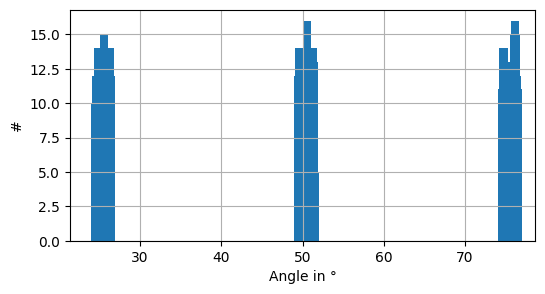

In [6]:
plt.figure(figsize=(6, 3))
plt.hist(A[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Angle in °")  # Adjustment place
plt.show()

In [7]:
y = A[targets]  # A -> Angle # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [8]:
params_path = "params/TrainValid_A_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=80,
        verbose=1,
    )
    grid.fit(EIT, y)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Loaded params
beste parameter: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [9]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.9729
Fold 2 Balanced Accuracy: 0.9793
Fold 3 Balanced Accuracy: 0.9777
Fold 4 Balanced Accuracy: 0.9905
Fold 5 Balanced Accuracy: 0.9618

Mean Balanced Accuracy: 0.9764411027568922
Std Balanced Accuracy: 0.009307602701637293

accuracy_score: 0.9764481222151495
balanced_accuracy_score: 0.9764448770387221
r2_score: 0.9546539310586011



Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1047
         1.0       0.97      0.96      0.97      1047
         2.0       0.97      0.99      0.98      1048

    accuracy                           0.98      3142
   macro avg       0.98      0.98      0.98      3142
weighted avg       0.98      0.98      0.98      3142



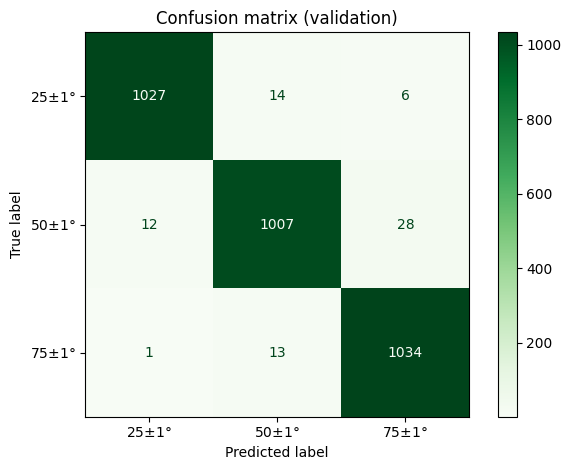

In [10]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_A_RF.pdf", bbox_inches="tight")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [11]:
params_path = "params/TrainTest_A_RF.pkl"  # Adjustment place

cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=80,
        verbose=1,
        refit=True,
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Loaded params
Best parameter: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [12]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3352
Fold 2 Accuracy: 0.3642
Fold 3 Accuracy: 0.3593
Fold 4 Accuracy: 0.3784
Fold 5 Accuracy: 0.3661

Mean Accuracy: 0.36064943930730525
Std Accuracy: 0.014175542911125969

accuracy_score 0.36123488224061107
balanced_accuracy_score 0.36120376648658103



Classification Report:
              precision    recall  f1-score   support

         0.0       0.36      0.41      0.38      1047
         1.0       0.35      0.21      0.27      1047
         2.0       0.36      0.46      0.41      1048

    accuracy                           0.36      3142
   macro avg       0.36      0.36      0.35      3142
weighted avg       0.36      0.36      0.35      3142



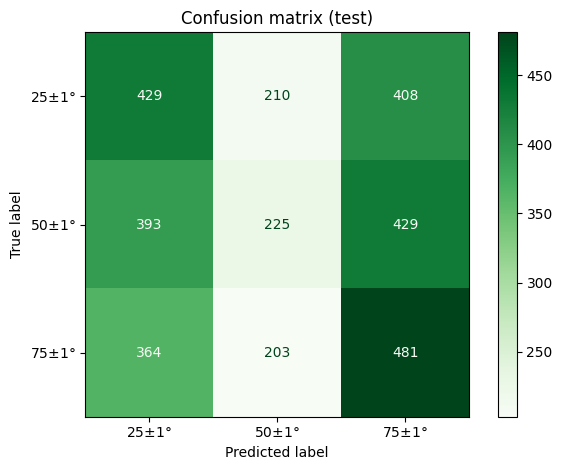

In [13]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_A_RF.pdf", bbox_inches="tight")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow T|_{\mathrm{targets}}$

In [14]:
p1s = indices_with_tolerance(T, 30, tol=1)  # Adjustment place
p2s = indices_with_tolerance(T, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(T, 70, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"50$\pm$20Nm", r"125$\pm$20Nm", r"200$\pm$20Nm"]  # Adjustment place
np.random.shuffle(targets)

Found 2,523 for position 30 and a tolerance of 1.
Found 1,953 for position 50 and a tolerance of 1.
Found 1,249 for position 70 and a tolerance of 1.


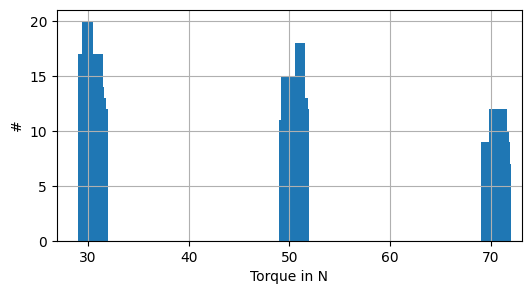

In [15]:
plt.figure(figsize=(6, 3))
plt.hist(T[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in Nm")  # Adjustment place
plt.show()

In [16]:
y = T[targets]  # T -> Torque # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [17]:
params_path = "params/TrainValid_T_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=80,
        verbose=1,
    )
    grid.fit(EIT, y)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Loaded params
beste parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [18]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.7817
Fold 2 Balanced Accuracy: 0.7957
Fold 3 Balanced Accuracy: 0.7695
Fold 4 Balanced Accuracy: 0.7833
Fold 5 Balanced Accuracy: 0.7711

Mean Balanced Accuracy: 0.7802512905782065
Std Balanced Accuracy: 0.009487403974345833

accuracy_score: 0.7802620087336245
balanced_accuracy_score: 0.7802523556993446
r2_score: 0.6350536903992454



Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.83      0.82      1908
         1.0       0.68      0.68      0.68      1908
         2.0       0.84      0.84      0.84      1909

    accuracy                           0.78      5725
   macro avg       0.78      0.78      0.78      5725
weighted avg       0.78      0.78      0.78      5725



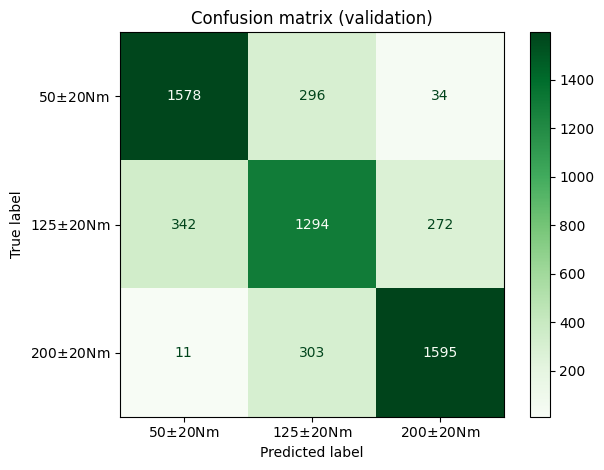

In [19]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_T_RF.pdf", bbox_inches="tight")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [20]:
params_path = "params/TrainTest_T_RF.pkl"  # Adjustment place

cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=80,
        verbose=1,
        refit=True,
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Loaded params
Best parameter: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [21]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3436
Fold 2 Accuracy: 0.3522
Fold 3 Accuracy: 0.3590
Fold 4 Accuracy: 0.3417
Fold 5 Accuracy: 0.2921

Mean Accuracy: 0.33772423331501145
Std Accuracy: 0.02365727437639518

accuracy_score 0.34323144104803494
balanced_accuracy_score 0.34326660392367025



Classification Report:
              precision    recall  f1-score   support

         0.0       0.31      0.18      0.23      1908
         1.0       0.36      0.70      0.47      1908
         2.0       0.33      0.14      0.20      1909

    accuracy                           0.34      5725
   macro avg       0.33      0.34      0.30      5725
weighted avg       0.33      0.34      0.30      5725



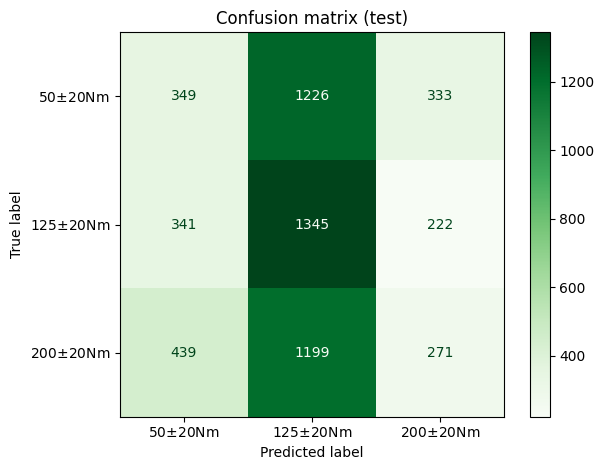

In [22]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_T_RF.pdf", bbox_inches="tight")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

In [36]:
p1s = indices_with_tolerance(F, 50, tol=2)  # Adjustment place
p2s = indices_with_tolerance(F, 125, tol=2)  # Adjustment place
p3s = indices_with_tolerance(F, 200, tol=2)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$2N", r"100$\pm$2N", r"175$\pm$2N"]  # Adjustment place
np.random.shuffle(targets)

Found 1,208 for position 50 and a tolerance of 2.
Found 1,545 for position 125 and a tolerance of 2.
Found 901 for position 200 and a tolerance of 2.


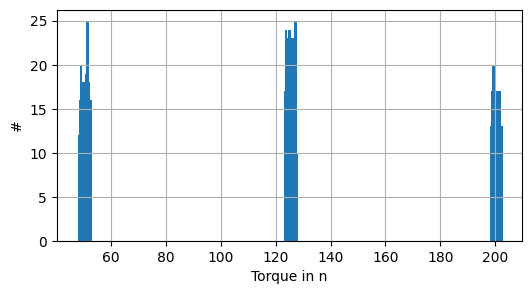

In [37]:
plt.figure(figsize=(6, 3))
plt.hist(F[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Force in N")
plt.show()

In [25]:
y = F[targets]  # F -> Force # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [26]:
params_path = "params/TrainValid_F_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=80,
        verbose=1,
    )
    grid.fit(EIT, y)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Loaded params
beste parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [27]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.8495
Fold 2 Balanced Accuracy: 0.8154
Fold 3 Balanced Accuracy: 0.8360
Fold 4 Balanced Accuracy: 0.8522
Fold 5 Balanced Accuracy: 0.8438

Mean Balanced Accuracy: 0.839368998628258
Std Balanced Accuracy: 0.013216083545766094

accuracy_score: 0.8393541324575807
balanced_accuracy_score: 0.8393541324575807
r2_score: 0.6506568144499179



Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89      1218
         1.0       0.78      0.83      0.80      1218
         2.0       0.84      0.81      0.83      1218

    accuracy                           0.84      3654
   macro avg       0.84      0.84      0.84      3654
weighted avg       0.84      0.84      0.84      3654



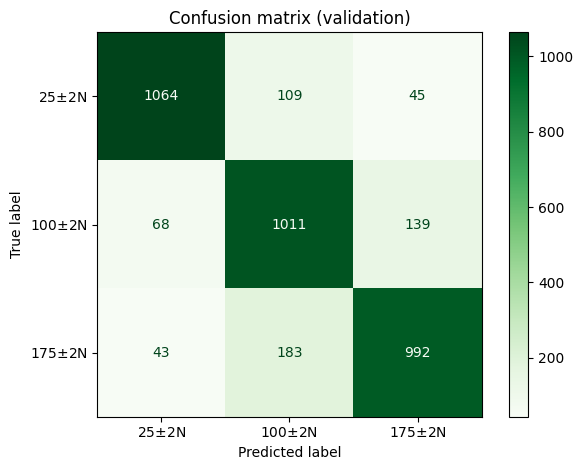

In [28]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_F_RF.pdf", bbox_inches="tight")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [29]:
params_path = "params/TrainTest_F_RF.pkl"  # Adjustment place

cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=80,
        verbose=1,
        refit=True,
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = grid.best_params_
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Loaded params
Best parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 10}


In [30]:
best_model = RandomForestClassifier(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3954
Fold 2 Accuracy: 0.2967
Fold 3 Accuracy: 0.3523
Fold 4 Accuracy: 0.3405
Fold 5 Accuracy: 0.3644

Mean Accuracy: 0.34986118220355256
Std Accuracy: 0.03226329584201573

accuracy_score 0.3522167487684729
balanced_accuracy_score 0.35221674876847286



Classification Report:
              precision    recall  f1-score   support

         0.0       0.35      0.58      0.44      1218
         1.0       0.33      0.11      0.17      1218
         2.0       0.37      0.36      0.36      1218

    accuracy                           0.35      3654
   macro avg       0.35      0.35      0.32      3654
weighted avg       0.35      0.35      0.32      3654



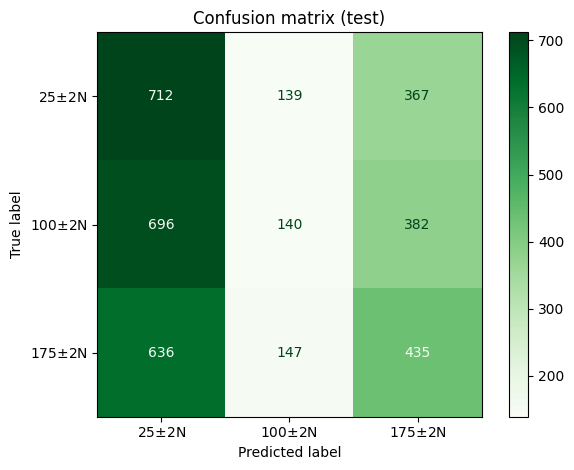

In [31]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_F_RF.pdf", bbox_inches="tight")  # Adjustment place
plt.show()

___